In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pycaret.regression import *

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, PowerTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

In [2]:
player_data = pd.read_csv('./rolled_data_24_25.csv')

gk_data = player_data[player_data['position'] == 'Goalkeeper']
def_data = player_data[player_data['position'] == 'Defender']
mid_data = player_data[player_data['position'] == 'Midfielder']
fwd_data = player_data[player_data['position'] == 'Forward']

In [3]:
# player_data.columns.tolist()

# GK


In [4]:
feats_gk = [
    'value', 'win_prob', 'xP', 'points_1_ewm', 'xP_3_ewm', 'minutes_5_ewm', 'yellow_cards_3_ewm', 'clean_sheets_per_90_3_ewm', 'saves_per_90_3_ewm',
    'expected_goals_conceded_per_90_3_ewm',  'goals_prevented_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'opponent_xG_3_ewm', 'shots_faced_3_ewm'
    ]

working_gk_df  = gk_data[feats_gk]

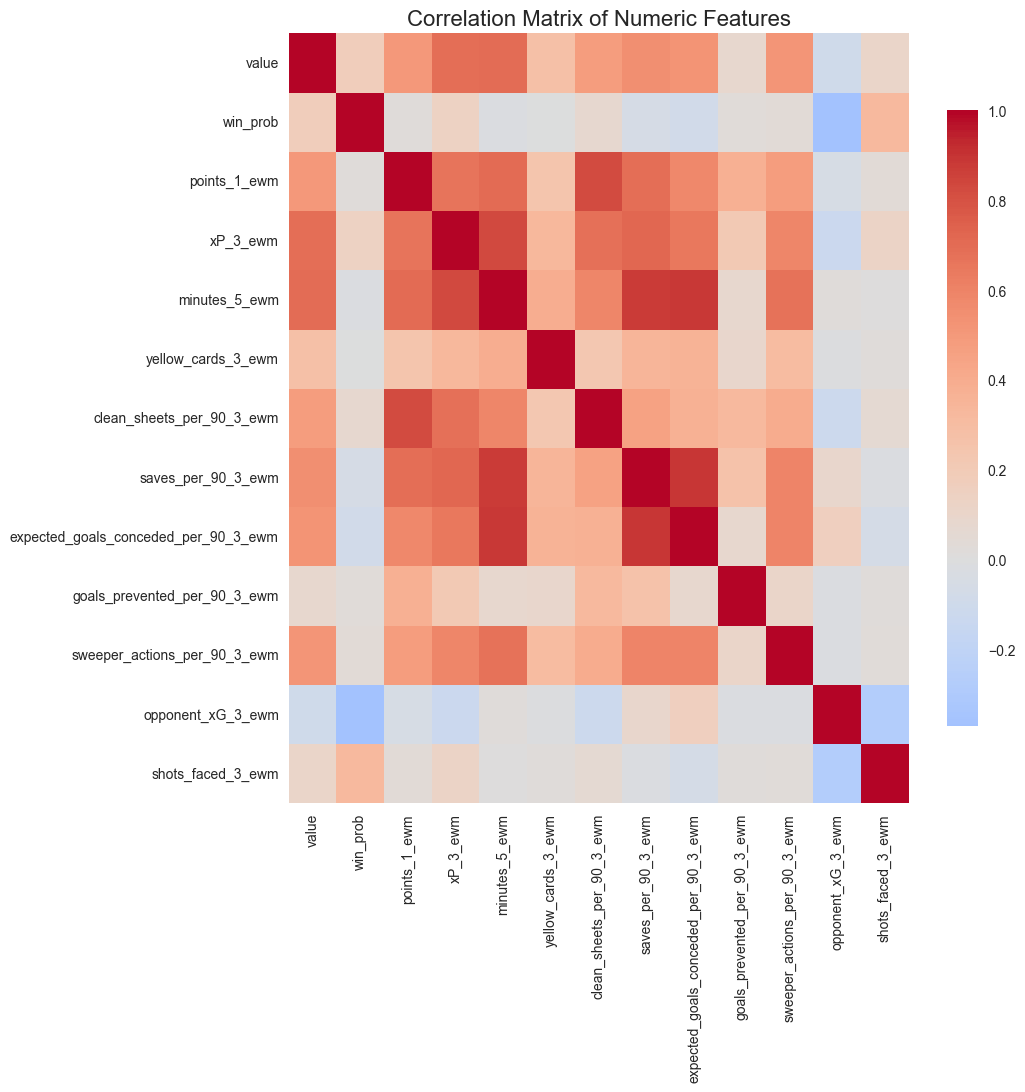

In [5]:
# Select only numeric features (exclude the target 'price')
numeric_df = working_gk_df.select_dtypes(include=['float64', 'int64']).drop(columns=["xP"], errors="ignore")

# Compute correlation matrix
corr_matrix = numeric_df.corr()


# Display full matrix as heatmap
plt.figure(figsize=(10,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,   # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

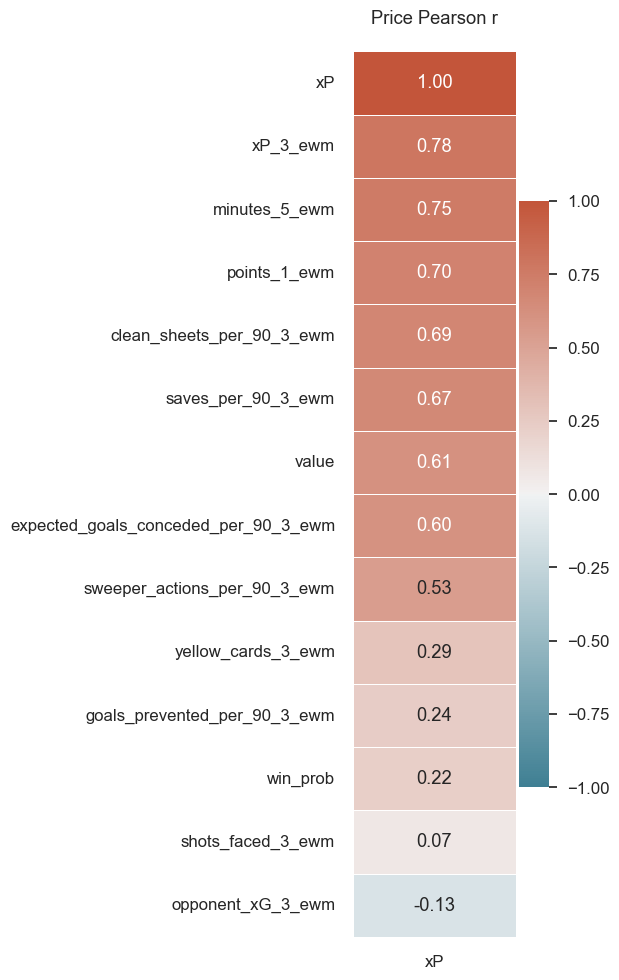

In [6]:

# Compute correlations with price
num_cols = working_gk_df.select_dtypes("number").columns
corr_vec  = working_gk_df[feats_gk].corr(method="pearson")["xP"].sort_values(ascending=False)
sns.set_theme(style="white")
sns.set(font_scale=1.1)
plt.figure(figsize=(6,10))
ax = sns.heatmap(
        corr_vec.to_frame(),
        annot=True, fmt=".2f",
        vmin=-1, vmax=1,
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        linewidths=.5, linecolor="white",
        cbar_kws={"shrink":0.8, "pad":0.02}
     )
ax.set_title("Price Pearson r", pad=20)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [7]:
final_gk_data = working_gk_df[feats_gk]
final_gk_data[['round', 'element', 'was_home']] = gk_data[['round', 'element','was_home']]
# Convert boolean to integer (True -> 1, False -> 0)
final_gk_data["was_home"] = final_gk_data["was_home"].astype(int)
final_gk_data = final_gk_data.fillna(0)
final_gk_data

,value,win_prob,xP,points_1_ewm,xP_3_ewm,minutes_5_ewm,yellow_cards_3_ewm,clean_sheets_per_90_3_ewm,saves_per_90_3_ewm,expected_goals_conceded_per_90_3_ewm,goals_prevented_per_90_3_ewm,sweeper_actions_per_90_3_ewm,opponent_xG_3_ewm,shots_faced_3_ewm,round,element,was_home
148,40.0,0.801,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,1,5,1
149,40.0,0.536,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.470000,6.0000,2,5,0
150,40.0,0.715,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.755000,6.0000,3,5,1
151,40.0,0.413,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.257500,6.5000,4,5,0
152,40.0,0.211,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.018750,5.2500,5,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26820,40.0,0.207,0.0,0.0,-0.081250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.748125,2.0000,34,788,0
26821,40.0,0.199,0.0,0.0,-0.040625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.189062,4.5000,35,788,0
26822,40.0,0.499,0.0,0.0,-0.020313,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.024531,7.7500,36,788,1
26823,40.0,0.152,0.0,0.0,-0.010156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.292266,6.3750,37,788,0


## Baseline Model


In [8]:
from pycaret.regression import *

import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from sklearn.preprocessing import test

from pycaret.regression import *

In [9]:
final_gk_data
gk_df = final_gk_data[(final_gk_data['minutes_5_ewm'] > 30)]
gk_df

,value,win_prob,xP,points_1_ewm,xP_3_ewm,minutes_5_ewm,yellow_cards_3_ewm,clean_sheets_per_90_3_ewm,saves_per_90_3_ewm,expected_goals_conceded_per_90_3_ewm,goals_prevented_per_90_3_ewm,sweeper_actions_per_90_3_ewm,opponent_xG_3_ewm,shots_faced_3_ewm,round,element,was_home
485,44.0,0.426,2.0,3.0,0.925000,50.000000,0.000000,0.0,4.500000,2.030000,0.560000,0.500000,2.855000,2.875000,5,14,1
486,44.0,0.190,2.2,3.0,1.462500,63.333333,0.000000,0.0,4.750000,1.860000,1.305000,1.250000,2.272500,2.937500,6,14,0
487,44.0,0.056,1.0,2.0,1.831250,72.222222,0.000000,0.0,3.875000,1.620000,-0.037500,1.125000,1.736250,3.468750,7,14,0
488,44.0,0.413,1.2,2.0,1.415625,78.148148,0.000000,0.0,3.437500,2.225000,-0.188750,0.562500,2.063125,2.734375,8,14,1
489,44.0,0.056,0.7,1.0,1.307812,82.098765,0.000000,0.0,2.218750,2.717500,-0.329375,0.281250,2.636563,4.867188,9,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26503,45.0,0.073,0.0,1.0,0.490625,87.658893,0.375000,0.0,4.472656,2.413594,-0.145684,1.101562,2.473906,2.294922,34,764,0
26504,45.0,0.143,0.7,1.0,0.245312,88.439262,0.187500,0.0,3.236328,2.631797,-0.572842,0.550781,2.401953,2.147461,35,764,0
26505,45.0,0.189,1.0,1.0,0.472656,88.959508,0.093750,0.0,2.118164,1.590898,-0.546421,1.775391,2.070977,2.073730,36,764,1
26506,45.0,0.326,1.5,3.0,0.736328,89.306339,0.046875,0.0,3.059082,1.500449,-0.173210,0.887695,1.640488,3.036865,37,764,0


In [10]:
final_gk_data

,value,win_prob,xP,points_1_ewm,xP_3_ewm,minutes_5_ewm,yellow_cards_3_ewm,clean_sheets_per_90_3_ewm,saves_per_90_3_ewm,expected_goals_conceded_per_90_3_ewm,goals_prevented_per_90_3_ewm,sweeper_actions_per_90_3_ewm,opponent_xG_3_ewm,shots_faced_3_ewm,round,element,was_home
148,40.0,0.801,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,1,5,1
149,40.0,0.536,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.470000,6.0000,2,5,0
150,40.0,0.715,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.755000,6.0000,3,5,1
151,40.0,0.413,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.257500,6.5000,4,5,0
152,40.0,0.211,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.018750,5.2500,5,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26820,40.0,0.207,0.0,0.0,-0.081250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.748125,2.0000,34,788,0
26821,40.0,0.199,0.0,0.0,-0.040625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.189062,4.5000,35,788,0
26822,40.0,0.499,0.0,0.0,-0.020313,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.024531,7.7500,36,788,1
26823,40.0,0.152,0.0,0.0,-0.010156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.292266,6.3750,37,788,0


In [11]:
gk_tar = gk_df['xP']
gk_feats = gk_df.drop(columns=['xP'])
gk_tar

485      2.0
486      2.2
487      1.0
488      1.2
489      0.7
        ... 
26503    0.0
26504    0.7
26505    1.0
26506    1.5
26507    0.7
Name: xP, Length: 793, dtype: float64

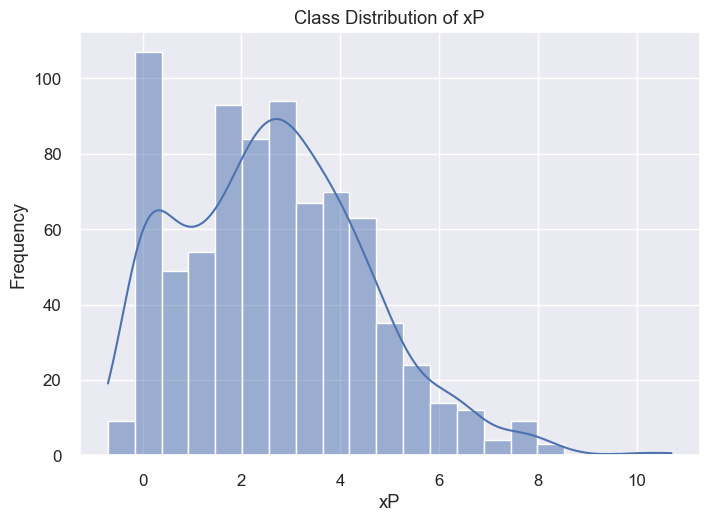

In [12]:
sns.histplot(gk_tar, kde=True)
plt.title('Class Distribution of xP')
plt.xlabel('xP')
plt.ylabel('Frequency')
plt.show()

<Axes: ylabel='Count'>

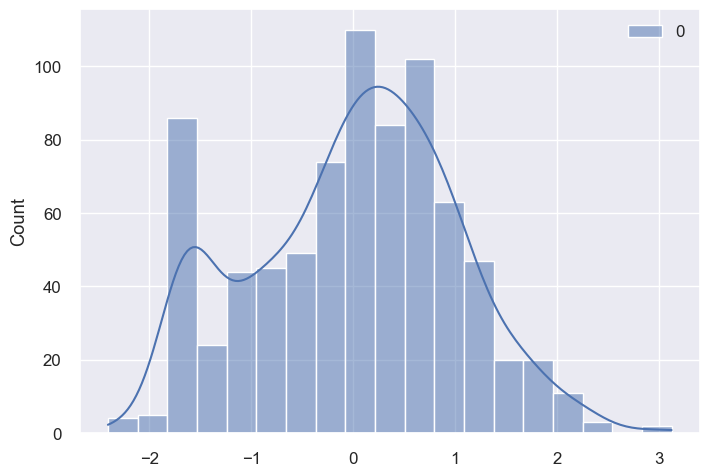

In [13]:
pt_xp = PowerTransformer(method='yeo-johnson', standardize=True)
v = pt_xp.fit_transform(gk_tar.values.reshape(-1,1))

sns.histplot(v, kde=True)

## Pycaret


In [14]:

models = {}
for i in [6, 10, 20, 30]:
    train_data = final_gk_data[(final_gk_data['round'] < i) & (final_gk_data['minutes_5_ewm'] > 15)][feats_gk]
    test_data = final_gk_data[final_gk_data['round'] == i][feats_gk]

    y_train = train_data['xP']
    X_train = train_data.drop(columns='xP')

    y_test = test_data['xP']
    X_test = test_data.drop(columns='xP')


    print(f'Modelling for gameweek {i}')
    model = setup(train_data, target = 'xP', train_size=0.8, session_id=42)

    model_best = model.compare_models(sort='MAE', n_select=1)

    models[i] = model_best


Modelling for gameweek 6


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(92, 14)"
4,Transformed data shape,"(92, 14)"
5,Transformed train set shape,"(73, 14)"
6,Transformed test set shape,"(19, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,1.0171,1.8576,1.3111,0.2362,0.3437,0.5409,0.0100
huber,Huber Regressor,1.0398,1.9071,1.3394,0.2757,0.3612,0.5026,0.0160
lr,Linear Regression,1.0577,1.9199,1.3394,0.2149,0.3525,0.5622,0.3640
br,Bayesian Ridge,1.0731,1.9183,1.3238,0.1939,0.3510,0.5995,0.0110
et,Extra Trees Regressor,1.1157,2.0109,1.3939,0.1812,0.3691,0.6086,0.0360
ada,AdaBoost Regressor,1.1335,1.9308,1.3731,0.2310,0.3892,0.7290,0.0300
rf,Random Forest Regressor,1.1596,2.0382,1.4078,0.1897,0.3858,0.6436,0.0530
en,Elastic Net,1.1689,2.1579,1.4181,0.1261,0.3771,0.7439,0.0090
gbr,Gradient Boosting Regressor,1.2107,2.5184,1.5535,-0.0140,0.3963,0.5819,0.0210
lasso,Lasso Regression,1.2353,2.3183,1.4754,0.1045,0.3928,0.8202,0.2410


Modelling for gameweek 10


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(186, 14)"
4,Transformed data shape,"(186, 14)"
5,Transformed train set shape,"(148, 14)"
6,Transformed test set shape,"(38, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


...

,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(435, 14)"
4,Transformed data shape,"(435, 14)"
5,Transformed train set shape,"(348, 14)"
6,Transformed test set shape,"(87, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7788,1.0698,1.0192,0.6725,0.3226,0.4992,0.0070
lr,Linear Regression,0.7803,1.0702,1.0195,0.6722,0.3234,0.4998,0.0060
br,Bayesian Ridge,0.7815,1.0825,1.0252,0.6687,0.3237,0.5010,0.0080
huber,Huber Regressor,0.7867,1.0946,1.0302,0.6639,0.3264,0.5113,0.0120
lar,Least Angle Regression,0.7937,1.1166,1.0414,0.6587,0.3286,0.5064,0.0060
et,Extra Trees Regressor,0.7985,1.1240,1.0463,0.6561,0.3386,0.5532,0.0390
rf,Random Forest Regressor,0.8280,1.2020,1.0813,0.6307,0.3436,0.5613,0.0660
gbr,Gradient Boosting Regressor,0.8326,1.2074,1.0853,0.6238,0.3497,0.5558,0.0360
ada,AdaBoost Regressor,0.8926,1.4085,1.1762,0.5679,0.3661,0.6514,0.0230
lightgbm,Light Gradient Boosting Machine,0.8944,1.4161,1.1788,0.5622,0.3717,0.5707,19.4970


Modelling for gameweek 30


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(689, 14)"
4,Transformed data shape,"(689, 14)"
5,Transformed train set shape,"(551, 14)"
6,Transformed test set shape,"(138, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.8971,1.5912,1.2473,0.5660,0.3958,0.4822,0.0150
et,Extra Trees Regressor,0.8978,1.5752,1.2409,0.5656,0.3965,0.5315,0.0790
ridge,Ridge Regression,0.9000,1.5931,1.2461,0.5654,0.3998,0.4975,0.0110
lr,Linear Regression,0.9007,1.5943,1.2462,0.5651,0.4002,0.4967,0.0090
br,Bayesian Ridge,0.9030,1.6069,1.2525,0.5617,0.4013,0.5014,0.0080
lar,Least Angle Regression,0.9092,1.6231,1.2563,0.5568,0.4023,0.4993,0.0080
gbr,Gradient Boosting Regressor,0.9163,1.6191,1.2572,0.5541,0.4068,0.5400,0.0480
rf,Random Forest Regressor,0.9227,1.6664,1.2759,0.5427,0.4040,0.5528,0.0990
lightgbm,Light Gradient Boosting Machine,0.9927,1.8138,1.3285,0.5018,0.4221,0.5717,31.1630
en,Elastic Net,1.0491,1.9829,1.3960,0.4619,0.4401,0.7232,0.0080


In [15]:
import optuna
model_6 = models[6]

# 3. Perform automated hyperparameter optimization
tuned_model_6 = tune_model(
    model_6,
    optimize="MAE",               # Metric to optimize
    n_iter=50,                   # Number of search iterations
    search_library="optuna",     # Engines: 'scikit-learn', 'optuna', 'scikit-optimize'
    search_algorithm="tpe",      # Algorithms: 'random', 'grid', 'bayesian', 'tpe'
    choose_better=True           # Reverts to base model if tuning degrades score
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9615,1.7390,1.3187,0.5342,0.4583,0.5946
1,0.7475,0.9485,0.9739,0.6989,0.3828,0.4286
2,0.8744,1.4104,1.1876,0.3661,0.4331,0.4811
3,0.8187,1.2864,1.1342,0.7197,0.3396,0.4296
4,0.8232,1.2279,1.1081,0.7247,0.3991,0.4563
5,1.1254,2.2500,1.5000,0.4576,0.4991,0.4972
6,0.8704,1.8823,1.3720,0.4504,0.4077,0.5071
7,0.9797,1.5970,1.2637,0.5296,0.3859,0.4458
8,1.0252,2.5783,1.6057,0.4828,0.3861,0.5526


In [18]:
tuned_models = {}
for idx, model in models.items():
    # 3. Perform automated hyperparameter optimization
    print(f'Tunning for gameweek {idx}: {model}')
    tuned_models[idx] = tune_model(
        model,
        optimize="MAE",               # Metric to optimize
        n_iter=50,                   # Number of search iterations
        search_library="optuna",     # Engines: 'scikit-learn', 'optuna', 'scikit-optimize'
        search_algorithm="tpe",      # Algorithms: 'random', 'grid', 'bayesian', 'tpe'
        choose_better=True           # Reverts to base model if tuning degrades score
        session_id=42
    )

Tunning for gameweek 6: Ridge(random_state=42)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9616,1.7393,1.3188,0.5341,0.4584,0.5946
1,0.7476,0.9484,0.9739,0.6989,0.3828,0.4286
2,0.8744,1.4102,1.1875,0.3662,0.4331,0.4810
3,0.8186,1.2861,1.1340,0.7198,0.3396,0.4295
4,0.8233,1.2278,1.1081,0.7247,0.3991,0.4563
5,1.1253,2.2501,1.5000,0.4576,0.4991,0.4972
6,0.8704,1.8825,1.3720,0.4504,0.4077,0.5070
7,0.9797,1.5971,1.2638,0.5296,0.3859,0.4458
8,1.0253,2.5782,1.6057,0.4828,0.3861,0.5526


Tunning for gameweek 10: LinearRegression(n_jobs=-1)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9674,1.7720,1.3312,0.5254,0.4629,0.5953
1,0.7544,0.9448,0.9720,0.7001,0.3823,0.4374
2,0.8672,1.3907,1.1793,0.3749,0.4302,0.4741
3,0.8127,1.2501,1.1181,0.7276,0.3349,0.4242
4,0.8249,1.2211,1.1050,0.7262,0.3994,0.4591
5,1.1148,2.2636,1.5045,0.4544,0.4985,0.4903
6,0.8718,1.9041,1.3799,0.4441,0.4093,0.4945
7,0.9836,1.6076,1.2679,0.5265,0.3883,0.4513
8,1.0319,2.5698,1.6031,0.4845,0.3880,0.5529


Tunning for gameweek 20: Ridge(random_state=42)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9640,1.7549,1.3247,0.5299,0.4605,0.5948
1,0.7509,0.9460,0.9726,0.6997,0.3826,0.4329
2,0.8708,1.3999,1.1832,0.3708,0.4316,0.4775
3,0.8156,1.2676,1.1259,0.7238,0.3371,0.4268
4,0.8241,1.2240,1.1064,0.7255,0.3991,0.4576
5,1.1202,2.2558,1.5019,0.4562,0.4987,0.4938
6,0.8712,1.8927,1.3758,0.4474,0.4085,0.5008
7,0.9817,1.6016,1.2656,0.5283,0.3870,0.4485
8,1.0286,2.5735,1.6042,0.4838,0.3870,0.5528


Tunning for gameweek 30: HuberRegressor()


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9499,1.6639,1.2899,0.5543,0.4476,0.5646
1,0.7752,1.0278,1.0138,0.6737,0.3945,0.4455
2,0.8649,1.3905,1.1792,0.3750,0.4257,0.4558
3,0.8061,1.3551,1.1641,0.7048,0.3394,0.4336
4,0.8426,1.2984,1.1395,0.7089,0.3938,0.4846
5,1.1105,2.1634,1.4708,0.4785,0.4955,0.4874
6,0.8693,1.8694,1.3673,0.4542,0.4051,0.4888
7,0.9786,1.5367,1.2396,0.5474,0.3821,0.4227
8,1.0213,2.6231,1.6196,0.4738,0.3789,0.5264
